# Notebook 10: Final Integrated Model Evaluation

## Overview & Purpose
This notebook synthesizes evaluation results from Notebooks 5 through 9 into a single, comprehensive final assessment of the XGBoost default prediction model on the held-out test dataset.

### Key Objectives:
1. **Artifact Ingestion:** Load final model artifacts, held-out test predictions, calibration metrics, feature importances (SHAP and Permutation), and risk segmentation definitions from previous pipeline steps.
2. **Final Performance Evaluation:** Evaluate core model performance on the held-out test set using both probability-based metrics (\(ROC-AUC\), \(PR-AUC\), \(Brier\ Score\), \(Log\ Loss\)) and threshold-dependent classification metrics.
3. **Threshold Decision Boundary Comparison:** Compare performance at the selected primary operational threshold ($0.24$, selected via maximum \(F_1\) score) directly against the baseline threshold ($0.50$) to evaluate operational trade-offs in Precision, Recall, and Specificity.
4. **Diagnostic Curve Generation:** Plot and export high-resolution Receiver Operating Characteristic (\(ROC\)) and Precision-Recall (\(PR\)) curves to visually summarize overall model discrimination capability.
5. **Calibration Review:** Record and consolidate post-hoc probability calibration results from Notebook 7 to document final probabilistic reliability.
6. **Feature Importance Synthesis:** Rank and contrast global feature importance across SHAP values and Permutation Importance from Notebook 8 to identify primary default risk drivers.
7. **Risk Group Segmentation:** Re-evaluate and plot observed vs. predicted default rates across broad risk tiers to assess operational risk stratification.
8. **Consolidated Artifact Export:** Generate and export final summary evaluation tables and diagnostic plots for model governance and final report generation.

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc,
    classification_report
)

from IPython.display import display

#### Load Notebook 8/9 artifacts

In [6]:
import os

# Match the path structure used in Notebook 9
possible_paths = [
    os.path.join("outputs", "final_artifacts"),
    os.path.join("notebook8_outputs", "final_artifacts"),
    os.path.join("final_artifacts")
]

ARTIFACT_DIR = None
for path in possible_paths:
    if os.path.exists(path):
        ARTIFACT_DIR = path
        break

if ARTIFACT_DIR is None:
    ARTIFACT_DIR = os.path.join("outputs", "final_artifacts")

OUTPUT_DIR_10 = os.path.join("outputs", "notebook_10")
os.makedirs(OUTPUT_DIR_10, exist_ok=True)

print("Artifact directory resolved to:", os.path.abspath(ARTIFACT_DIR))
print("Notebook 10 output directory:", os.path.abspath(OUTPUT_DIR_10))

# Essential required files to run Notebook 10
required_files = [
    "final_base_model.joblib",
    "X_model_train.joblib",
    "y_model_train.joblib",
    "X_calibration.joblib",
    "y_calibration.joblib",
    "X_test.joblib",
    "y_test.joblib",
    "train_prob.joblib",
    "calibration_prob.joblib",
    "test_prob.joblib",
    "shap_original_df.joblib",
    "permutation_importance_df.joblib"
]

missing = [
    filename
    for filename in required_files
    if not os.path.exists(os.path.join(ARTIFACT_DIR, filename))
]

if missing:
    print("Missing artifacts:")
    for filename in missing:
        print("-", filename)
    raise FileNotFoundError(f"Required artifacts missing in '{ARTIFACT_DIR}'.")

print("✓ All essential required artifacts found.")

Artifact directory resolved to: c:\Users\rayan\OneDrive\Desktop\Credit_Risk\Credit-Risk-Scoring-System\notebooks\notebook8_outputs\final_artifacts
Notebook 10 output directory: c:\Users\rayan\OneDrive\Desktop\Credit_Risk\Credit-Risk-Scoring-System\notebooks\outputs\notebook_10
✓ All essential required artifacts found.


In [7]:
import os

# Match the path structure used in Notebook 9
possible_paths = [
    os.path.join("outputs", "final_artifacts"),
    os.path.join("notebook8_outputs", "final_artifacts"),
    os.path.join("final_artifacts")
]

ARTIFACT_DIR = None
for path in possible_paths:
    if os.path.exists(path):
        ARTIFACT_DIR = path
        break

if ARTIFACT_DIR is None:
    ARTIFACT_DIR = os.path.join("outputs", "final_artifacts")

OUTPUT_DIR_10 = os.path.join("outputs", "notebook_10")
os.makedirs(OUTPUT_DIR_10, exist_ok=True)

print("Artifact directory resolved to:", os.path.abspath(ARTIFACT_DIR))
print("Notebook 10 output directory:", os.path.abspath(OUTPUT_DIR_10))

# Essential required files to run Notebook 10
required_files = [
    "final_base_model.joblib",
    "X_model_train.joblib",
    "y_model_train.joblib",
    "X_calibration.joblib",
    "y_calibration.joblib",
    "X_test.joblib",
    "y_test.joblib",
    "train_prob.joblib",
    "calibration_prob.joblib",
    "test_prob.joblib",
    "shap_original_df.joblib",
    "permutation_importance_df.joblib"
]

missing = [
    filename
    for filename in required_files
    if not os.path.exists(os.path.join(ARTIFACT_DIR, filename))
]

if missing:
    print("Missing artifacts:")
    for filename in missing:
        print("-", filename)
    raise FileNotFoundError(f"Required artifacts missing in '{ARTIFACT_DIR}'.")

print("✓ All essential required artifacts found.")

Artifact directory resolved to: c:\Users\rayan\OneDrive\Desktop\Credit_Risk\Credit-Risk-Scoring-System\notebooks\notebook8_outputs\final_artifacts
Notebook 10 output directory: c:\Users\rayan\OneDrive\Desktop\Credit_Risk\Credit-Risk-Scoring-System\notebooks\outputs\notebook_10
✓ All essential required artifacts found.


#### Load Artifacts

In [8]:
import os
import joblib

# Core artifacts
final_base_model = joblib.load(os.path.join(ARTIFACT_DIR, "final_base_model.joblib"))
X_model_train = joblib.load(os.path.join(ARTIFACT_DIR, "X_model_train.joblib"))
y_model_train = joblib.load(os.path.join(ARTIFACT_DIR, "y_model_train.joblib"))
X_calibration = joblib.load(os.path.join(ARTIFACT_DIR, "X_calibration.joblib"))
y_calibration = joblib.load(os.path.join(ARTIFACT_DIR, "y_calibration.joblib"))
X_test = joblib.load(os.path.join(ARTIFACT_DIR, "X_test.joblib"))
y_test = joblib.load(os.path.join(ARTIFACT_DIR, "y_test.joblib"))

train_prob = joblib.load(os.path.join(ARTIFACT_DIR, "train_prob.joblib"))
calibration_prob = joblib.load(os.path.join(ARTIFACT_DIR, "calibration_prob.joblib"))
test_prob = joblib.load(os.path.join(ARTIFACT_DIR, "test_prob.joblib"))

shap_original_df = joblib.load(os.path.join(ARTIFACT_DIR, "shap_original_df.joblib"))
permutation_importance_df = joblib.load(os.path.join(ARTIFACT_DIR, "permutation_importance_df.joblib"))

# Optional DataFrames 
res_path = os.path.join(ARTIFACT_DIR, "final_test_results_df.joblib")
final_test_results_df = joblib.load(res_path) if os.path.exists(res_path) else None

cal_path = os.path.join(ARTIFACT_DIR, "test_calibration_error_df.joblib")
test_calibration_error_df = joblib.load(cal_path) if os.path.exists(cal_path) else None

print("✓ All artifacts loaded successfully.")

✓ All artifacts loaded successfully.


#### Verify shapes and probability alignment

In [9]:
print("=" * 75)
print("NOTEBOOK 10 - DATA VERIFICATION")
print("=" * 75)

print("\nShapes")
print("-" * 75)
print("X_model_train:", X_model_train.shape)
print("y_model_train:", y_model_train.shape)
print("X_calibration:", X_calibration.shape)
print("y_calibration:", y_calibration.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nProbability shapes")
print("-" * 75)
print("train_prob:", train_prob.shape)
print("calibration_prob:", calibration_prob.shape)
print("test_prob:", test_prob.shape)

assert len(X_model_train) == len(y_model_train) == len(train_prob)
assert len(X_calibration) == len(y_calibration) == len(calibration_prob)
assert len(X_test) == len(y_test) == len(test_prob)

assert np.isfinite(train_prob).all()
assert np.isfinite(calibration_prob).all()
assert np.isfinite(test_prob).all()

assert ((train_prob >= 0) & (train_prob <= 1)).all()
assert ((calibration_prob >= 0) & (calibration_prob <= 1)).all()
assert ((test_prob >= 0) & (test_prob <= 1)).all()

print("\n✓ All shape and probability checks passed.")

NOTEBOOK 10 - DATA VERIFICATION

Shapes
---------------------------------------------------------------------------
X_model_train: (19200, 23)
y_model_train: (19200,)
X_calibration: (4800, 23)
y_calibration: (4800,)
X_test: (6000, 23)
y_test: (6000,)

Probability shapes
---------------------------------------------------------------------------
train_prob: (19200,)
calibration_prob: (4800,)
test_prob: (6000,)

✓ All shape and probability checks passed.


#### Define the final threshold

In [10]:
SELECTED_THRESHOLD = 0.24
BASELINE_THRESHOLD = 0.50

print("Selected threshold:", SELECTED_THRESHOLD)
print("Baseline threshold:", BASELINE_THRESHOLD)

Selected threshold: 0.24
Baseline threshold: 0.5


#### Final test metrics at threshold 0.24

In [11]:
test_pred_selected = (
    test_prob >= SELECTED_THRESHOLD
).astype(int)

test_pred_baseline = (
    test_prob >= BASELINE_THRESHOLD
).astype(int)

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC",
        "Brier Score",
        "Log Loss"
    ],
    "Value": [
        accuracy_score(y_test, test_pred_selected),
        balanced_accuracy_score(y_test, test_pred_selected),
        precision_score(y_test, test_pred_selected, zero_division=0),
        recall_score(y_test, test_pred_selected, zero_division=0),
        f1_score(y_test, test_pred_selected, zero_division=0),
        roc_auc_score(y_test, test_prob),
        average_precision_score(y_test, test_prob),
        brier_score_loss(y_test, test_prob),
        log_loss(y_test, test_prob)
    ]
})

display(final_metrics.round(6))

,Metric,Value
0,Accuracy,0.779667
1,Balanced Accuracy,0.717448
2,Precision,0.501560
3,Recall,0.605878
4,F1,0.548805
5,ROC-AUC,0.780532
6,PR-AUC,0.560152
7,Brier Score,0.135042
8,Log Loss,0.429563


#### Compare threshold 0.50 and threshold 0.24

In [12]:
threshold_comparison = []

for name, threshold in [
    ("0.50 Baseline", BASELINE_THRESHOLD),
    ("0.24 Selected", SELECTED_THRESHOLD)
]:
    pred = (test_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        pred,
        labels=[0, 1]
    ).ravel()

    threshold_comparison.append({
        "Threshold": name,
        "Value": threshold,
        "Accuracy": accuracy_score(y_test, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "Specificity": tn / (tn + fp),
        "F1": f1_score(y_test, pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

threshold_comparison_df = pd.DataFrame(threshold_comparison)

display(
    threshold_comparison_df.round(6)
)

,Threshold,Value,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1,TN,FP,FN,TP
0,0.50 Baseline,0.50,0.819333,0.655770,0.668985,0.362472,0.949069,0.470186,4435,238,846,481
1,0.24 Selected,0.24,0.779667,0.717448,0.501560,0.605878,0.829018,0.548805,3874,799,523,804


#### Confusion matrix at selected threshold

In [13]:
cm_selected = confusion_matrix(
    y_test,
    test_pred_selected,
    labels=[0, 1]
)

print("Confusion Matrix - Threshold 0.24")
print(cm_selected)

print("\nClassification Report - Threshold 0.24")
print(
    classification_report(
        y_test,
        test_pred_selected,
        target_names=["Non-Default", "Default"],
        zero_division=0
    )
)

Confusion Matrix - Threshold 0.24
[[3874  799]
 [ 523  804]]

Classification Report - Threshold 0.24
              precision    recall  f1-score   support

 Non-Default       0.88      0.83      0.85      4673
     Default       0.50      0.61      0.55      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.72      0.70      6000
weighted avg       0.80      0.78      0.79      6000



#### ROC curve

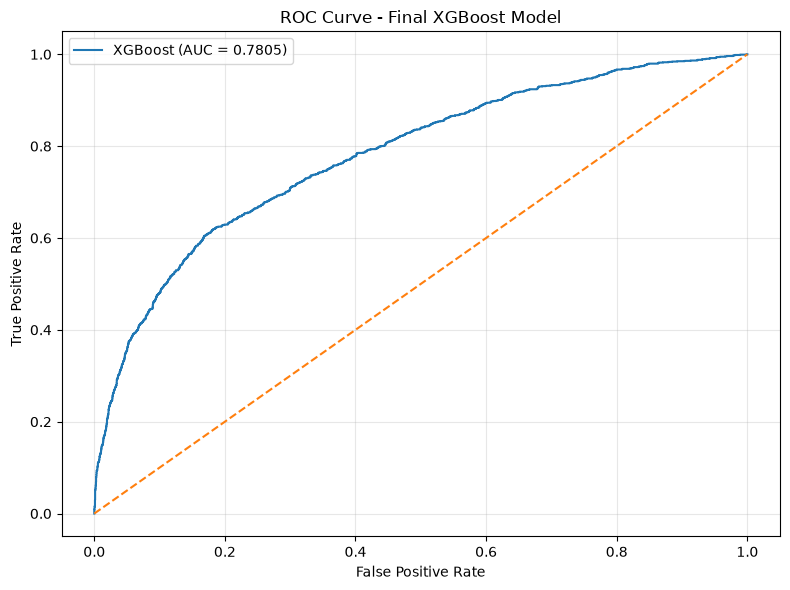

In [14]:
fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    test_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc:.4f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final XGBoost Model")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR_10,
        "final_roc_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Precision-Recall curve

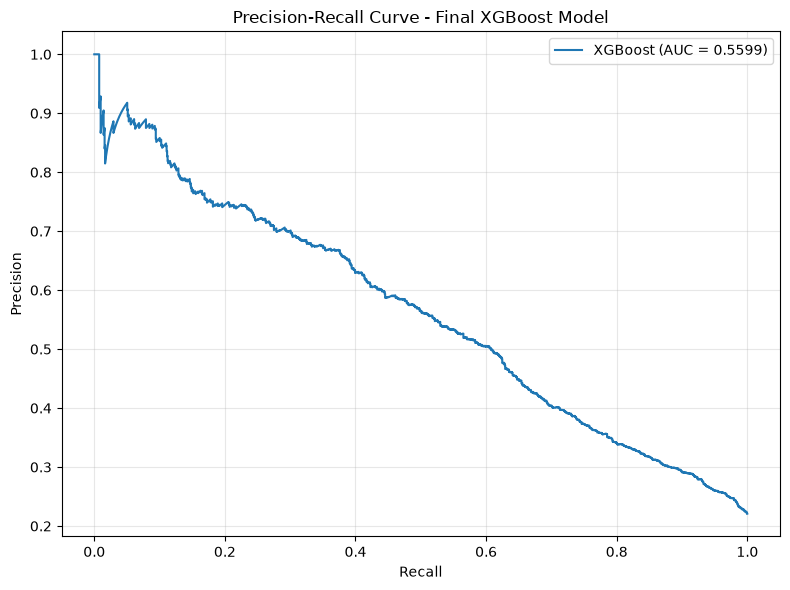

In [15]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test,
    test_prob
)

pr_auc = auc(
    recall_curve,
    precision_curve
)

plt.figure(figsize=(8, 6))
plt.plot(
    recall_curve,
    precision_curve,
    label=f"XGBoost (AUC = {pr_auc:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final XGBoost Model")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR_10,
        "final_precision_recall_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Calibration comparison

In [16]:
calibration_comparison = pd.DataFrame({
    "Method": [
        "Uncalibrated",
        "Sigmoid",
        "Isotonic"
    ],
    "Brier Score": [
        0.135183,
        0.136268,
        0.135642
    ],
    "Log Loss": [
        0.430089,
        0.434392,
        0.437038
    ],
    "ROC-AUC": [
        0.779086,
        0.779086,
        0.775755
    ],
    "PR-AUC": [
        0.558452,
        0.558452,
        0.544534
    ]
})

display(calibration_comparison)

,Method,Brier Score,Log Loss,ROC-AUC,PR-AUC
0,Uncalibrated,0.135183,0.430089,0.779086,0.558452
1,Sigmoid,0.136268,0.434392,0.779086,0.558452
2,Isotonic,0.135642,0.437038,0.775755,0.544534


#### Top SHAP features

In [17]:
print("=" * 75)
print("TOP FEATURES - SHAP")
print("=" * 75)

display(
    shap_original_df.head(10)
)

TOP FEATURES - SHAP


,Original Feature,Mean Absolute SHAP
0,PAY_0,0.513383
1,LIMIT_BAL,0.204634
2,BILL_AMT1,0.141599
3,PAY_2,0.111160
4,PAY_AMT2,0.103172
5,PAY_AMT1,0.093487
6,PAY_3,0.089967
7,PAY_AMT3,0.075334
8,PAY_AMT6,0.057464
9,PAY_6,0.055402


#### Top permutation-importance features

In [18]:
print("=" * 75)
print("TOP FEATURES - PERMUTATION IMPORTANCE")
print("=" * 75)

display(
    permutation_importance_df.head(10)
)

TOP FEATURES - PERMUTATION IMPORTANCE


,Feature,Importance Mean,Importance Std
0,PAY_0,0.073660,0.006757
1,LIMIT_BAL,0.025160,0.004562
2,BILL_AMT1,0.008098,0.003297
3,PAY_2,0.004352,0.002877
4,PAY_4,0.003559,0.002166
5,PAY_AMT2,0.003243,0.002569
6,PAY_3,0.003224,0.002581
7,BILL_AMT3,0.002645,0.001372
8,BILL_AMT4,0.002447,0.001016
9,PAY_AMT6,0.002246,0.001407


#### Compare SHAP and permutation importance

In [19]:
shap_top = (
    shap_original_df
    .head(10)
    .copy()
)

permutation_top = (
    permutation_importance_df
    .head(10)
    .copy()
)

print("Top 10 SHAP features")
display(shap_top)

print("\nTop 10 permutation-importance features")
display(permutation_top)

Top 10 SHAP features


,Original Feature,Mean Absolute SHAP
0,PAY_0,0.513383
1,LIMIT_BAL,0.204634
2,BILL_AMT1,0.141599
3,PAY_2,0.111160
4,PAY_AMT2,0.103172
5,PAY_AMT1,0.093487
6,PAY_3,0.089967
7,PAY_AMT3,0.075334
8,PAY_AMT6,0.057464
9,PAY_6,0.055402



Top 10 permutation-importance features


,Feature,Importance Mean,Importance Std
0,PAY_0,0.073660,0.006757
1,LIMIT_BAL,0.025160,0.004562
2,BILL_AMT1,0.008098,0.003297
3,PAY_2,0.004352,0.002877
4,PAY_4,0.003559,0.002166
5,PAY_AMT2,0.003243,0.002569
6,PAY_3,0.003224,0.002581
7,BILL_AMT3,0.002645,0.001372
8,BILL_AMT4,0.002447,0.001016
9,PAY_AMT6,0.002246,0.001407


#### Test risk groups

In [20]:
risk_bins = [
    0.00,
    0.10,
    0.20,
    0.30,
    0.50,
    1.00
]

risk_labels = [
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
]

risk_group = pd.cut(
    test_prob,
    bins=risk_bins,
    labels=risk_labels,
    include_lowest=True,
    right=False
)

final_risk_data = pd.DataFrame({
    "Predicted_Probability": test_prob,
    "Actual_Default": np.asarray(y_test),
    "Risk_Group": risk_group
})

risk_summary = (
    final_risk_data
    .groupby(
        "Risk_Group",
        observed=False
    )
    .agg(
        Customers=("Actual_Default", "size"),
        Mean_Probability=("Predicted_Probability", "mean"),
        Actual_Default_Rate=("Actual_Default", "mean")
    )
    .reset_index()
)

risk_summary["Calibration_Error"] = (
    risk_summary["Actual_Default_Rate"]
    - risk_summary["Mean_Probability"]
)

display(
    risk_summary.round(6)
)

,Risk_Group,Customers,Mean_Probability,Actual_Default_Rate,Calibration_Error
0,Very Low,1687,0.068874,0.062241,-0.006634
1,Low,2331,0.141765,0.151008,0.009243
2,Moderate,696,0.240515,0.241379,0.000864
3,High,567,0.380088,0.389771,0.009682
4,Very High,719,0.694706,0.668985,-0.025721


#### Verify risk-group totals

In [21]:
total_risk_customers = risk_summary["Customers"].sum()

print("Risk-group customers:", total_risk_customers)
print("Test customers:", len(y_test))

assert total_risk_customers == len(y_test)

print("✓ All test observations are assigned to a risk group.")

Risk-group customers: 6000
Test customers: 6000
✓ All test observations are assigned to a risk group.


#### Risk-group calibration plot

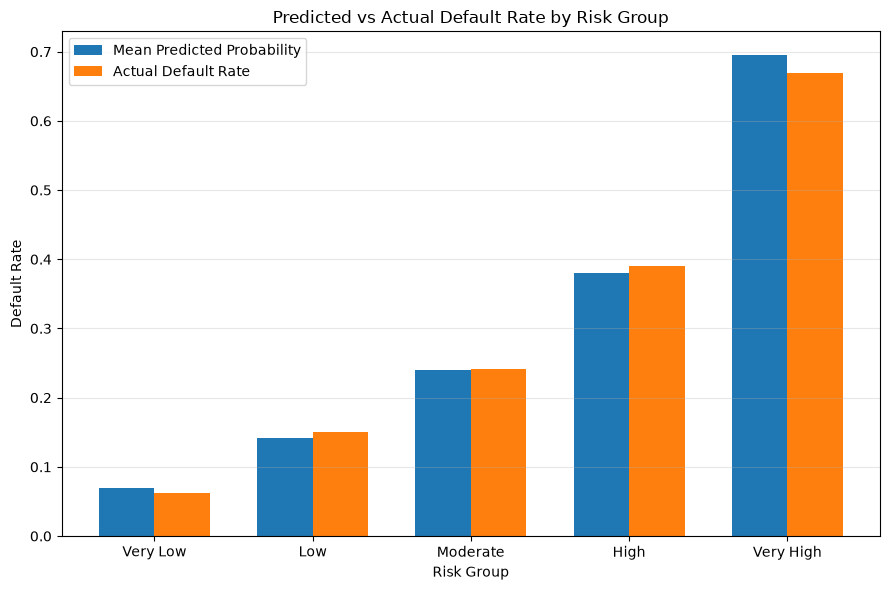

In [22]:
x = np.arange(len(risk_summary))
width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(
    x - width / 2,
    risk_summary["Mean_Probability"],
    width,
    label="Mean Predicted Probability"
)

plt.bar(
    x + width / 2,
    risk_summary["Actual_Default_Rate"],
    width,
    label="Actual Default Rate"
)

plt.xticks(
    x,
    risk_summary["Risk_Group"]
)

plt.ylabel("Default Rate")
plt.xlabel("Risk Group")
plt.title("Predicted vs Actual Default Rate by Risk Group")
plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR_10,
        "final_risk_group_calibration.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### High-risk segment

In [23]:
high_risk_mask = test_prob >= 0.50

high_risk_count = high_risk_mask.sum()
high_risk_proportion = high_risk_count / len(test_prob)
high_risk_actual_default_rate = y_test[high_risk_mask].mean()

print("High-risk threshold: 0.50")
print("Customers:", high_risk_count)
print("Proportion of test set:", round(high_risk_proportion, 6))
print(
    "Actual default rate:",
    round(high_risk_actual_default_rate, 6)
)

High-risk threshold: 0.50
Customers: 719
Proportion of test set: 0.119833
Actual default rate: 0.668985


#### Final integrated results table

In [24]:
integrated_results = pd.DataFrame({
    "Section": [
        "Model",
        "Model",
        "Model",
        "Threshold",
        "Threshold",
        "Threshold",
        "Threshold",
        "Threshold",
        "Probability",
        "Probability",
        "Probability",
        "Risk"
    ],
    "Metric": [
        "Algorithm",
        "Training Observations",
        "Test Observations",
        "Selected Threshold",
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "ROC-AUC",
        "PR-AUC",
        "Brier Score",
        "High-Risk Actual Default Rate"
    ],
    "Value": [
        "XGBoost",
        len(X_model_train),
        len(X_test),
        SELECTED_THRESHOLD,
        accuracy_score(y_test, test_pred_selected),
        balanced_accuracy_score(y_test, test_pred_selected),
        precision_score(y_test, test_pred_selected, zero_division=0),
        recall_score(y_test, test_pred_selected, zero_division=0),
        roc_auc_score(y_test, test_prob),
        average_precision_score(y_test, test_prob),
        brier_score_loss(y_test, test_prob),
        high_risk_actual_default_rate
    ]
})

display(
    integrated_results
)

,Section,Metric,Value
0,Model,Algorithm,XGBoost
1,Model,Training Observations,19200
2,Model,Test Observations,6000
3,Threshold,Selected Threshold,0.24
4,Threshold,Accuracy,0.779667
5,Threshold,Balanced Accuracy,0.717448
6,Threshold,Precision,0.50156
7,Threshold,Recall,0.605878
8,Probability,ROC-AUC,0.780532
9,Probability,PR-AUC,0.560152


#### Save outputs

In [25]:
final_metrics.to_csv(
    os.path.join(
        OUTPUT_DIR_10,
        "final_test_metrics.csv"
    ),
    index=False
)

threshold_comparison_df.to_csv(
    os.path.join(
        OUTPUT_DIR_10,
        "final_threshold_comparison.csv"
    ),
    index=False
)

calibration_comparison.to_csv(
    os.path.join(
        OUTPUT_DIR_10,
        "final_calibration_comparison.csv"
    ),
    index=False
)

risk_summary.to_csv(
    os.path.join(
        OUTPUT_DIR_10,
        "final_risk_group_summary.csv"
    ),
    index=False
)

integrated_results.to_csv(
    os.path.join(
        OUTPUT_DIR_10,
        "final_integrated_results.csv"
    ),
    index=False
)

print("Notebook 10 tables saved successfully.")

Notebook 10 tables saved successfully.


#### Summary

In [26]:
print("=" * 75)
print("NOTEBOOK 10 - FINAL INTEGRATED EVALUATION")
print("=" * 75)

print("\nMODEL")
print("-" * 75)
print("Model: XGBoost")
print("Training observations:", len(X_model_train))
print("Calibration observations:", len(X_calibration))
print("Test observations:", len(X_test))

print("\nPROBABILITY PERFORMANCE")
print("-" * 75)
print(
    f"ROC-AUC: "
    f"{roc_auc_score(y_test, test_prob):.6f}"
)
print(
    f"PR-AUC: "
    f"{average_precision_score(y_test, test_prob):.6f}"
)
print(
    f"Brier Score: "
    f"{brier_score_loss(y_test, test_prob):.6f}"
)
print(
    f"Log Loss: "
    f"{log_loss(y_test, test_prob):.6f}"
)

print("\nSELECTED THRESHOLD")
print("-" * 75)
print("Threshold:", SELECTED_THRESHOLD)
print(
    f"Accuracy: "
    f"{accuracy_score(y_test, test_pred_selected):.6f}"
)
print(
    f"Balanced Accuracy: "
    f"{balanced_accuracy_score(y_test, test_pred_selected):.6f}"
)
print(
    f"Precision: "
    f"{precision_score(y_test, test_pred_selected, zero_division=0):.6f}"
)
print(
    f"Recall: "
    f"{recall_score(y_test, test_pred_selected, zero_division=0):.6f}"
)
print(
    f"F1: "
    f"{f1_score(y_test, test_pred_selected, zero_division=0):.6f}"
)

print("\nRISK SEGMENTATION")
print("-" * 75)
print("High-risk threshold: 0.50")
print("High-risk customers:", high_risk_count)
print(
    f"High-risk proportion: "
    f"{high_risk_proportion:.6f}"
)
print(
    f"High-risk actual default rate: "
    f"{high_risk_actual_default_rate:.6f}"
)

print("\nOUTPUT FILES")
print("-" * 75)

for filename in sorted(os.listdir(OUTPUT_DIR_10)):
    print(filename)

print("\nNotebook 10 completed.")

NOTEBOOK 10 - FINAL INTEGRATED EVALUATION

MODEL
---------------------------------------------------------------------------
Model: XGBoost
Training observations: 19200
Calibration observations: 4800
Test observations: 6000

PROBABILITY PERFORMANCE
---------------------------------------------------------------------------
ROC-AUC: 0.780532
PR-AUC: 0.560152
Brier Score: 0.135042
Log Loss: 0.429563

SELECTED THRESHOLD
---------------------------------------------------------------------------
Threshold: 0.24
Accuracy: 0.779667
Balanced Accuracy: 0.717448
Precision: 0.501560
Recall: 0.605878
F1: 0.548805

RISK SEGMENTATION
---------------------------------------------------------------------------
High-risk threshold: 0.50
High-risk customers: 719
High-risk proportion: 0.119833
High-risk actual default rate: 0.668985

OUTPUT FILES
---------------------------------------------------------------------------
final_calibration_comparison.csv
final_integrated_results.csv
final_precision_recal